#  Polynomial Regression

## When Linear Regression Fails

Sometimes data follows a curve, not a straight line.

Example: Plant growth vs water
- Too little water → plant dies
- Right amount → grows well
- Too much water → plant dies

This is a curve (parabola), not a line!

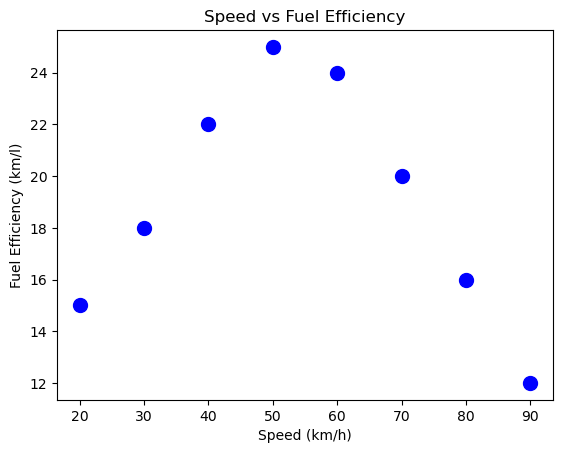

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Curved data: Speed vs Fuel Efficiency
# Slow: inefficient, Medium: efficient, Fast: inefficient
speed = np.array([20, 30, 40, 50, 60, 70, 80, 90]).reshape(-1, 1)
fuel_efficiency = np.array([15, 18, 22, 25, 24, 20, 16, 12])

plt.scatter(speed, fuel_efficiency, color='blue', s=100)
plt.xlabel("Speed (km/h)")
plt.ylabel("Fuel Efficiency (km/l)")
plt.title("Speed vs Fuel Efficiency")
plt.show()

## Try Linear Regression (Will Fail)

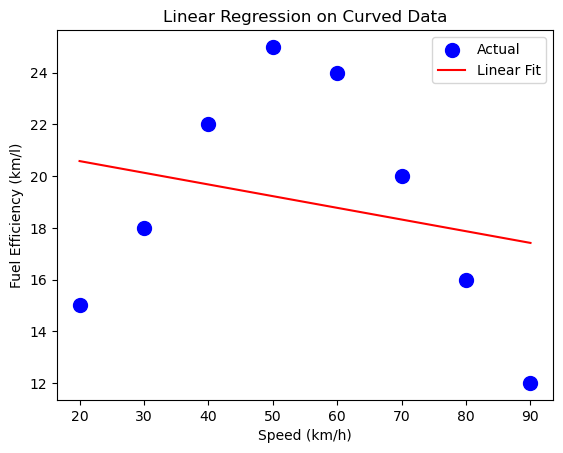

Linear R²: 0.0589


In [2]:
# Linear regression on curved data
linear_model = LinearRegression()
linear_model.fit(speed, fuel_efficiency)

# Predict
speed_range = np.linspace(20, 90, 100).reshape(-1, 1)
linear_pred = linear_model.predict(speed_range)

# Plot
plt.scatter(speed, fuel_efficiency, color='blue', s=100, label='Actual')
plt.plot(speed_range, linear_pred, color='red', label='Linear Fit')
plt.xlabel("Speed (km/h)")
plt.ylabel("Fuel Efficiency (km/l)")
plt.title("Linear Regression on Curved Data")
plt.legend()
plt.show()

# R² score
from sklearn.metrics import r2_score
linear_r2 = r2_score(fuel_efficiency, linear_model.predict(speed))
print(f"Linear R²: {linear_r2:.4f}")  # Will be low!

## Polynomial Regression: Add Squared Term

Instead of: y = mx + b
We use: y = ax² + bx + c

This creates a curve!

Original: [20 30 40]
Transformed: [[1.0e+00 2.0e+01 4.0e+02]
 [1.0e+00 3.0e+01 9.0e+02]
 [1.0e+00 4.0e+01 1.6e+03]]


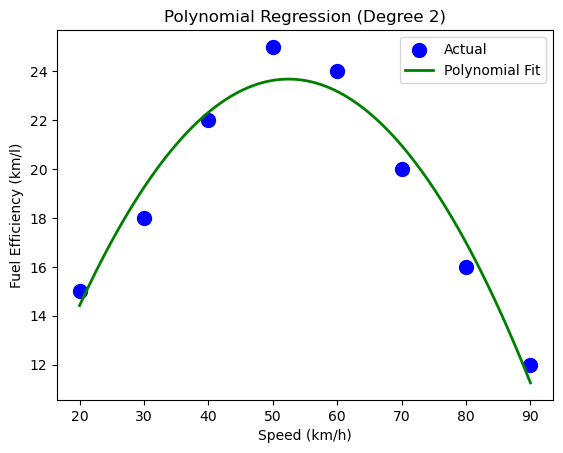

Polynomial R²: 0.9519


In [4]:
# Transform features: x → x, x²
poly = PolynomialFeatures(degree=2)  # x and x²
speed_poly = poly.fit_transform(speed)

print("Original:", speed[:3].flatten())
print("Transformed:", speed_poly[:3])

# Now fit linear regression on transformed features
poly_model = LinearRegression()
poly_model.fit(speed_poly, fuel_efficiency)

# Predict
speed_range_poly = poly.transform(speed_range)
poly_pred = poly_model.predict(speed_range_poly)

# Plot
plt.scatter(speed, fuel_efficiency, color='blue', s=100, label='Actual')
plt.plot(speed_range, poly_pred, color='green', linewidth=2, label='Polynomial Fit')
plt.xlabel("Speed (km/h)")
plt.ylabel("Fuel Efficiency (km/l)")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()
plt.show()

poly_r2 = r2_score(fuel_efficiency, poly_model.predict(speed_poly))
print(f"Polynomial R²: {poly_r2:.4f}")  # Much better!

## Try Different Degrees

Degree 1 = Line
Degree 2 = Parabola
Degree 3 = More complex curve

Higher degree = more flexible, but can overfit!

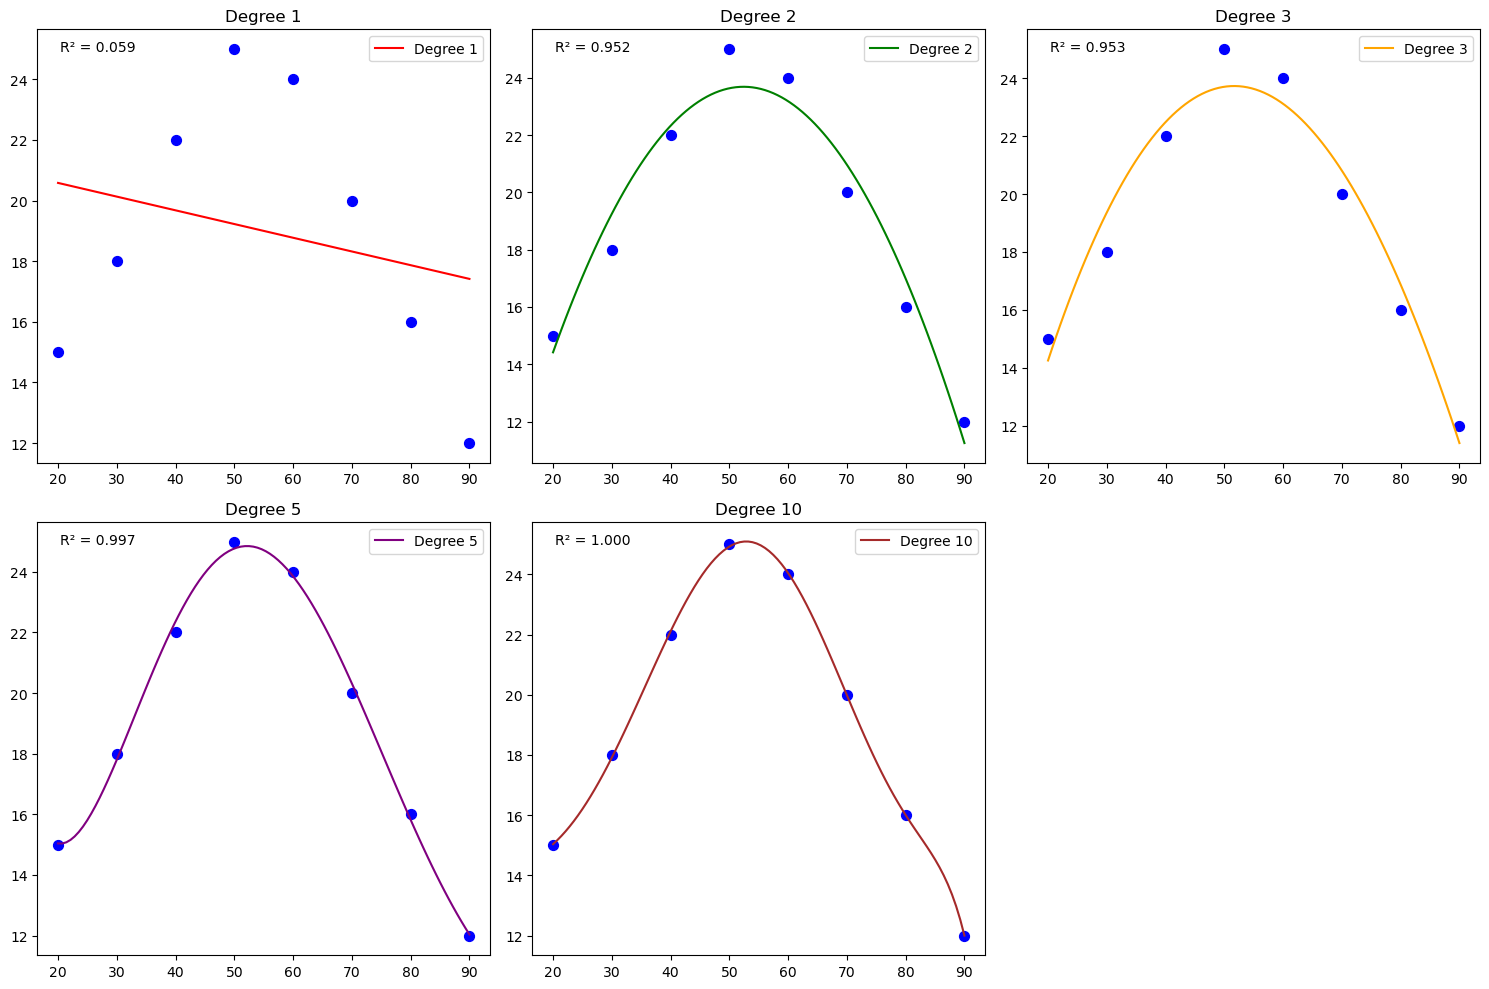

In [5]:
degrees = [1, 2, 3, 5, 10]
colors = ['red', 'green', 'orange', 'purple', 'brown']

plt.figure(figsize=(15, 10))

for i, degree in enumerate(degrees):
    plt.subplot(2, 3, i+1)
    
    # Fit polynomial
    poly = PolynomialFeatures(degree=degree)
    speed_poly = poly.fit_transform(speed)
    model = LinearRegression()
    model.fit(speed_poly, fuel_efficiency)
    
    # Predict
    speed_range_poly = poly.transform(speed_range)
    pred = model.predict(speed_range_poly)
    
    # Plot
    plt.scatter(speed, fuel_efficiency, color='blue', s=50)
    plt.plot(speed_range, pred, color=colors[i], label=f'Degree {degree}')
    plt.title(f'Degree {degree}')
    plt.legend()
    
    # R² score
    r2 = r2_score(fuel_efficiency, model.predict(speed_poly))
    plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()